# Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

**Submission Deadline**: Before next class

**Learning Objectives**:
- Master OSMnx road network extraction and projection
- Implement betweenness centrality analysis
- Construct rainfall → congestion dynamic weighting system
- Calculate pre/post-disaster isochrones and accessibility changes
- (Advanced) Use AI to generate disaster response recommendations

---


## Part 0: Environment Setup

Confirm the following packages are installed:`osmnx`, `networkx`, `geopandas`, `pandas`, `numpy`, `matplotlib`, `shapely`


In [1]:
# [S1] Environment Setup
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Check version
print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")

# Font configuration (If Chinese language support is needed)
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']  # fallback
rcParams['axes.unicode_minus'] = False


OSMnx: 2.0.7
NetworkX: 3.4.2
GeoPandas: 1.1.2


## Part A: Road Network Extraction & Travel Time Calculation

### Task A.1: Road Network Extraction

Use OSMnx to extract from OpenStreetMap**花蓮** (or choose your own township) road network.

**Tips**:
- Use `ox.graph_from_place()` or `ox.graph_from_address()`
- Set `network_type='drive'` Extract only car roads
- OSMnx ≥2.0 Road network already auto-simplified,no additional calls needed `simplify_graph()`
- use `ox.project_graph(G, to_crs='EPSG:3826')` Project to meter coordinates

In [2]:
# [S2] Attempt Road Network Extraction
# If using place name, confirm the location exists (e.g., "Hualien City, Taiwan")

place_name = "Hualien City, Taiwan"  # TODO: Change to your chosen location
network_type = 'drive'
dist_meters = 5000  # Search radius (meters)

print(f"📍 Extracting {place_name} road network...")

try:
    # TODO: Use ox.graph_from_address() to extract road network
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} Node(s), {G.number_of_edges()} edge(s)")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Possible causes:")
    print("  - Location name does not existor format error")
    print("  - Network connection issue (Overpass API Timeout)")
    print("  - Recommend waiting a few minutes and retry,oruse ox.settings.timeout = 300")


📍 Extracting Hualien City, Taiwan road network...


✅ Extraction successful: 3421 Node(s), 9815 edge(s)


In [3]:
# [S3] Project to Meter Coordinates
# Note: OSMnx >=2.0 automatically simplifies, no manual call needed simplify_graph()

# TODO: Project to EPSG:3826 (TWD97/TM2)
G_proj = ox.project_graph(G, to_crs='EPSG:3826')

print(f"Node count: {G_proj.number_of_nodes()}")
print(f"Number of edges: {G_proj.number_of_edges()}")
print(f"CRS: {G_proj.graph['crs']}")
print("✅ Projection complete")


Node count: 3421
Number of edges: 9815
CRS: EPSG:3826
✅ Projection complete


In [4]:
# [S4] Calculate Travel Time
# Calculate base travel time for each edge (unit: seconds)

# Highway type speed reference table (consistent with Demo Cell [3])
speed_defaults = {
    'motorway': 110, 'motorway_link': 80,
    'trunk': 100, 'trunk_link': 60,
    'primary': 80, 'primary_link': 50,
    'secondary': 60, 'secondary_link': 40,
    'tertiary': 50, 'tertiary_link': 30,
    'residential': 40, 'living_street': 10,
    'unclassified': 30,
}

def get_speed_kph(data):
    """From OSM edge data Get speed (km/h),and Demo Cell [3] Consistent."""
    maxspeed = data.get('maxspeed', None)
    if maxspeed:
        try:
            return float(maxspeed)
        except (ValueError, TypeError):
            if isinstance(maxspeed, list):
                try:
                    return float(maxspeed[0])
                except:
                    pass
    highway = data.get('highway', 'residential')
    if isinstance(highway, list):
        highway = highway[0]
    return speed_defaults.get(highway, 40)

# TODO: Traverse all edges,Calculate travel_time_normal
for u, v, k, data in G_proj.edges(data=True, keys=True):
    length = data['length']  # meters
    speed_kph = get_speed_kph(data)
    speed_ms = speed_kph / 3.6  # Convert to m/s
    data['travel_time_normal'] = length / speed_ms  # seconds
    data['speed_kph'] = speed_kph

# Check
sample_edge = list(G_proj.edges(data=True, keys=True))[0]
print(f"Sample edges: length={sample_edge[3]['length']:.1f}m, "
      f"speed={sample_edge[3]['speed_kph']:.0f}km/h, "
      f"travel_time={sample_edge[3]['travel_time_normal']:.1f}s")
print("✅ Travel time calculation complete")


Sample edges: length=17.7m, speed=30km/h, travel_time=2.1s
✅ Travel time calculation complete


## Part B: Bottleneck & Risk Assessment

### Task B.1: Calculate Betweenness Centrality & Identify Top 5


In [5]:
# [S5] Calculate Centrality
# Use NetworkX betweenness_centrality
# Use 'length' (road segment length) as weight

print("⏳ Calculating Betweenness Centrality...")

# TODO: Use nx.betweenness_centrality() Calculate
centrality = nx.betweenness_centrality(G_proj, weight='length')

print("✅ Calculation complete")

# TODO: Find Top 5 Node(s)
top_5_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Bottleneck Node(s):")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    print(f"{rank}. Node(s) {node_id}: Centrality = {cent_val:.6f}")


⏳ Calculating Betweenness Centrality...


✅ Calculation complete

Top 5 Bottleneck Node(s):
1. Node(s) 649286213: Centrality = 0.140247
2. Node(s) 649286214: Centrality = 0.139444
3. Node(s) 1061487893: Centrality = 0.125307
4. Node(s) 929963021: Centrality = 0.123480
5. Node(s) 1074772659: Centrality = 0.115733


### Task B.2: Overlay Top 5 with Terrain Risk (Using Week 4 Data)


In [6]:
# [S6] Terrain Risk Overlay (Advanced Option)
from shapely.geometry import Point
import geopandas as gpd

# Step 1: Convert Top 5 Nodes to GeoDataFrame
top_5_gdf = gpd.GeoDataFrame(
    [{'node_id': nid, 'centrality': cv,
      'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
     for nid, cv in top_5_nodes],
    crs=G_proj.graph['crs']
)
print(f"✅ Top 5 Node(s) GeoDataFrame Establishment complete")
print(top_5_gdf[['node_id', 'centrality']])

# Step 2 (Optional): Overlay W4 Terrain risk - skipped if data not available
# terrain_gdf = gpd.read_file('path/to/terrain_risk.geojson')
# top_5_with_risk = gpd.sjoin(top_5_gdf, terrain_gdf, how='left', predicate='within')


✅ Top 5 Node(s) GeoDataFrame Establishment complete
      node_id  centrality
0   649286213    0.140247
1   649286214    0.139444
2  1061487893    0.125307
3   929963021    0.123480
4  1074772659    0.115733


### Task B.3: Visualization


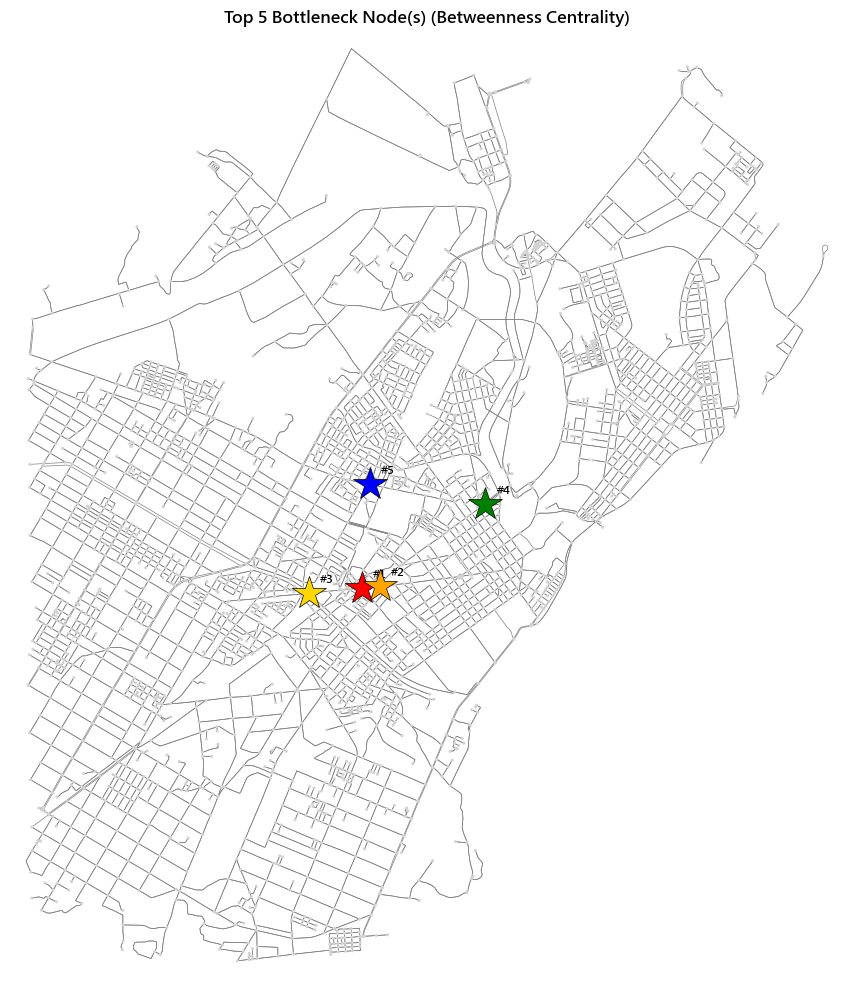

✅ Visualization complete


In [7]:
# [S7] Visualize Bottlenecks

fig, ax = plt.subplots(figsize=(12, 10))

# Draw the entire road network
ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
             edge_color='gray', edge_linewidth=0.5, show=False)

# Mark Top 5 Node(s) (Star marker)
colors = ['red', 'orange', 'gold', 'green', 'blue']
for rank, (node_id, cent_val) in enumerate(top_5_nodes):
    x = G_proj.nodes[node_id]['x']
    y = G_proj.nodes[node_id]['y']
    ax.plot(x, y, marker='*', markersize=25, color=colors[rank],
           markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    ax.annotate(f'#{rank+1}', (x, y), fontsize=8, fontweight='bold',
               textcoords='offset points', xytext=(8, 8))

ax.set_title('Top 5 Bottleneck Node(s) (Betweenness Centrality)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visualization complete")


## Part C: Dynamic Accessibility Analysis

> **⏱️ Lab 2 Scope (30 min in class)**:Complete the **core calculations** of C.1 ~ C.3 (print contraction ratiovalues).
> Part D visualization can be completed during assignment time, not required in class.

### Task C.1: Define Rainfall → Traffic Congestion Mapping


In [8]:
# [S8] Define rain_to_congestion Function

def rain_to_congestion(rainfall_mm, method='threshold'):
    if method == 'threshold':
        if rainfall_mm < 10:
            return 0.0
        elif rainfall_mm < 40:
            return 0.3
        elif rainfall_mm < 80:
            return 0.6
        else:
            return 0.9
    elif method == 'exponential':
        import math
        return 0.95 * (1 - math.exp(-rainfall_mm/50.0))
    elif method == 'linear':
        return min(rainfall_mm / 100 * 0.9, 0.95)
    return 0.0

# Testing
rain_test = [0, 10, 40, 80, 100, 130.5]
for rain in rain_test:
    cf = rain_to_congestion(rain, method='threshold')
    print(f"Rainfall {rain:.1f} mm/hr → Congestion Factor {cf}")


Rainfall 0.0 mm/hr → Congestion Factor 0.0
Rainfall 10.0 mm/hr → Congestion Factor 0.3
Rainfall 40.0 mm/hr → Congestion Factor 0.6
Rainfall 80.0 mm/hr → Congestion Factor 0.9
Rainfall 100.0 mm/hr → Congestion Factor 0.9
Rainfall 130.5 mm/hr → Congestion Factor 0.9


### Task C.2: Load Rainfall Data (W5/W6) and Apply Dynamic Weights


In [9]:
# [S9] Load Rainfall Data

print("✅ Rainfall data reading skipped; using simulated random data in S10")


✅ Rainfall data reading skipped; using simulated random data in S10


In [10]:
# [S10] Apply Dynamic Weights

def apply_dynamic_weights(G, rainfall_layer, congestion_method='threshold'):
    """
    Add dynamic weights to road network edges (and Demo Cell [11] Consistent).
    
    Parameters
    ----------
    G : networkx.MultiDiGraph
        Projected road network (needhave travel_time_normal attribute)
    rainfall_layer : dict
        Simulate rainfall data {node_id: rainfall_mm}
    congestion_method : str
        congestionvehicleMapping method ('threshold')
    
    Returns
    -------
    G_dyn : networkx.MultiDiGraph
        Graph with added 'travel_time_adj'
    """
    G_dyn = G.copy()
    
    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        # TODO: Get rainfall for this segment (or use fixed simulation value)
        # Tips: Use road segment midpoint coordinates to get value from rainfall_layer
        # Simple version: Use fixed simulation value
        rainfall_mm = rainfall_layer.get(u, 0)  # Get rainfall for Node u
        
        # TODO: use rain_to_congestion() CalculateCongestion Factor
        cf = rain_to_congestion(rainfall_mm, method=congestion_method)
        
        # TODO: Calculate post-disaster travel time
        tt_normal = data.get('travel_time_normal', data.get('travel_time', 60))
        speed_kph = data.get('speed_kph', 40)
        length = data['length']
        
        if cf >= 0.95:  # Almost completely impassable
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = length / ((speed_kph / 3.6) * (1 - cf))
        
        data['congestion_factor'] = cf
    
    return G_dyn

# Simulated rainfall layer (simple version: randomly assign rainfall to all nodes)
np.random.seed(42)
rainfall_layer = {
    node: np.random.choice([0, 5, 15, 25, 50, 65, 90, 130],
                           p=[0.2, 0.15, 0.15, 0.15, 0.15, 0.1, 0.05, 0.05])
    for node in G_proj.nodes()
}

G_dyn = apply_dynamic_weights(G_proj, rainfall_layer)

# Statistics
cfs = [d.get('congestion_factor', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
print(f"road segmentcount: {len(cfs)}")
print(f"Congestion distribution: cf=0: {cfs.count(0)}, cf=0.3: {cfs.count(0.3)}, cf=0.6: {cfs.count(0.6)}, cf=0.9: {cfs.count(0.9)}")
print("✅ Dynamic weight application complete")

# ⚠️ Sanity Check (class failure case reminder):
# 1. Is CRS EPSG:3826? → print(G_proj.graph.get('crs'))
# 2. Check travel_time_adj for outliers? → should not all be inf
adj_times = [d.get('travel_time_adj', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
inf_count = sum(1 for t in adj_times if t == float('inf'))
print(f"⚠️ Sanity: {inf_count}/{len(adj_times)} impassable segments (inf)")
if inf_count > len(adj_times) * 0.5:
    print("❌ Warning:More than half impassable segments,Check congestion_factor logic!")


road segmentcount: 9815
Congestion distribution: cf=0: 3474, cf=0.3: 2900, cf=0.6: 2514, cf=0.9: 927
✅ Dynamic weight application complete
⚠️ Sanity: 0/9815 impassable segments (inf)


### Task C.3: Calculate Isochrones and Accessibility Metrics


In [11]:
# [S11] Calculate Isochrones + Isochrone Polygons

from shapely.geometry import MultiPoint, Point, Polygon

def compute_isochrone(G, source_node, weight_attr, time_seconds):
    try:
        distances = nx.single_source_dijkstra_path_length(
            G, source_node, weight=weight_attr, cutoff=time_seconds
        )
    except Exception:
        distances = {}
    reachable_nodes = set(distances.keys())
    return reachable_nodes, distances

def nodes_to_polygon(G, nodes):
    if len(nodes) < 3:
        return None, 0.0
    points = [Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in nodes]
    mp = MultiPoint(points)
    polygon = mp.convex_hull
    if polygon.geom_type == 'Polygon':
        return polygon, polygon.area
    return None, 0.0

def get_adaptive_thresholds(G, source_node, weight_attr):
    """
    Adaptive thresholds. Minimum: 5 min (short), 10 min (long).
    """
    MIN_SHORT = 5 * 60
    MIN_LONG  = 10 * 60
    try:
        all_times = dict(nx.single_source_dijkstra_path_length(
            G, source_node, weight=weight_attr
        ))
        max_time = max(all_times.values()) if all_times else MIN_LONG * 2
    except Exception:
        max_time = MIN_LONG * 2
    t_short = max(max_time * 0.35, MIN_SHORT)
    t_long  = max(max_time * 0.65, MIN_LONG)
    return t_short, t_long

print("✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete")


✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete


In [12]:
# [S12] Calculate Accessibility Benefit-Cost Table (Adaptive Threshold)

# Select analysis starting points (use the first 3 of the Top 5 bottlenecks as critical facilities)
selected_facilities = top_5_nodes[:3]  # [(node_id, centrality_value), ...]
print(f"Analyze {len(selected_facilities)} accessibility changes for critical facilities:")

results = []

for facility_id, facility_cent in selected_facilities:
    # === Pre-disaster: Adaptive threshold ===
    t_short_b, t_long_b = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time')
    reachable_before_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_short_b)
    reachable_before_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_long_b)
    
    # === Post-disaster: Adaptive threshold ===
    t_short_a, t_long_a = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time_adj')
    reachable_after_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_short_a)
    reachable_after_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_long_a)
    
    # Calculatemultiplepolygonareaarea
    _, area_before_short = nodes_to_polygon(G_dyn, reachable_before_short)
    _, area_before_long  = nodes_to_polygon(G_dyn, reachable_before_long)
    _, area_after_short  = nodes_to_polygon(G_dyn, reachable_after_short)
    _, area_after_long   = nodes_to_polygon(G_dyn, reachable_after_long)
    
    # Area contraction at same threshold (Use pre-disaster threshold to compare reachable range at same threshold in post-disaster scenario)
    reachable_after_at_before_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_short_b)
    reachable_after_at_before_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_long_b)
    _, area_after_same_short = nodes_to_polygon(G_dyn, reachable_after_at_before_short)
    _, area_after_same_long  = nodes_to_polygon(G_dyn, reachable_after_at_before_long)
    
    shrink_short = (1 - area_after_same_short / area_before_short) * 100 if area_before_short > 0 else 0
    shrink_long  = (1 - area_after_same_long  / area_before_long)  * 100 if area_before_long  > 0 else 0
    
    results.append({
        'Facility/FacilitiesNode(s)': facility_id,
        'Centrality': f'{facility_cent:.4f}',
        f'Pre-disaster{t_short_b/60:.0f}min (km²)': f'{area_before_short/1e6:.2f}',
        f'Post-disaster{t_short_b/60:.0f}min (km²)': f'{area_after_same_short/1e6:.2f}',
        'Short-distance contraction %': f'{shrink_short:.1f}%',
        f'Pre-disaster{t_long_b/60:.0f}min (km²)': f'{area_before_long/1e6:.2f}',
        f'Post-disaster{t_long_b/60:.0f}min (km²)': f'{area_after_same_long/1e6:.2f}',
        'Long-distance contraction%': f'{shrink_long:.1f}%',
    })
    
    print(f"\n  Facility/Facilities {facility_id}: Threshold = {t_short_b/60:.1f} / {t_long_b/60:.1f} min")
    print(f"    Short-distance contraction: {shrink_short:.1f}%  Long-distance contraction: {shrink_long:.1f}%")

accessibility_table = pd.DataFrame(results)
print("\n📊 Accessibility benefit-cost table:")
print(accessibility_table.to_string(index=False))
print("\n✅ Accessibility benefit-cost table calculation complete")
accessibility_table.to_csv("accessibility_table.csv", index=False)
print("✅ Saved to accessibility_table.csv")


Analyze 3 accessibility changes for critical facilities:



  Facility/Facilities 649286213: Threshold = 5.0 / 10.0 min
    Short-distance contraction: 80.6%  Long-distance contraction: 29.8%



  Facility/Facilities 649286214: Threshold = 5.0 / 10.0 min
    Short-distance contraction: 77.2%  Long-distance contraction: 24.5%



  Facility/Facilities 1061487893: Threshold = 5.0 / 10.0 min
    Short-distance contraction: 79.3%  Long-distance contraction: 29.1%

📊 Accessibility benefit-cost table:
 Facility/FacilitiesNode(s) Centrality Pre-disaster5min (km²) Post-disaster5min (km²) Short-distance contraction % Pre-disaster10min (km²) Post-disaster10min (km²) Long-distance contraction%
                  649286213     0.1402                  64.79                   12.59                        80.6%                   64.79                    45.50                      29.8%
                  649286214     0.1394                  64.79                   14.76                        77.2%                   64.79                    48.89                      24.5%
                 1061487893     0.1253                  64.79                   13.42                        79.3%                   64.79                    45.94                      29.1%

✅ Accessibility benefit-cost table calculation complete
✅ Saved 

## Part D: Visualization (Before & After Comparison)

> **💡 Tip**:This visualization is an **extension goal** in Lab 2.
> If class timeInsufficient,Can be completed during assignment.The key is Part C numerical calculation.


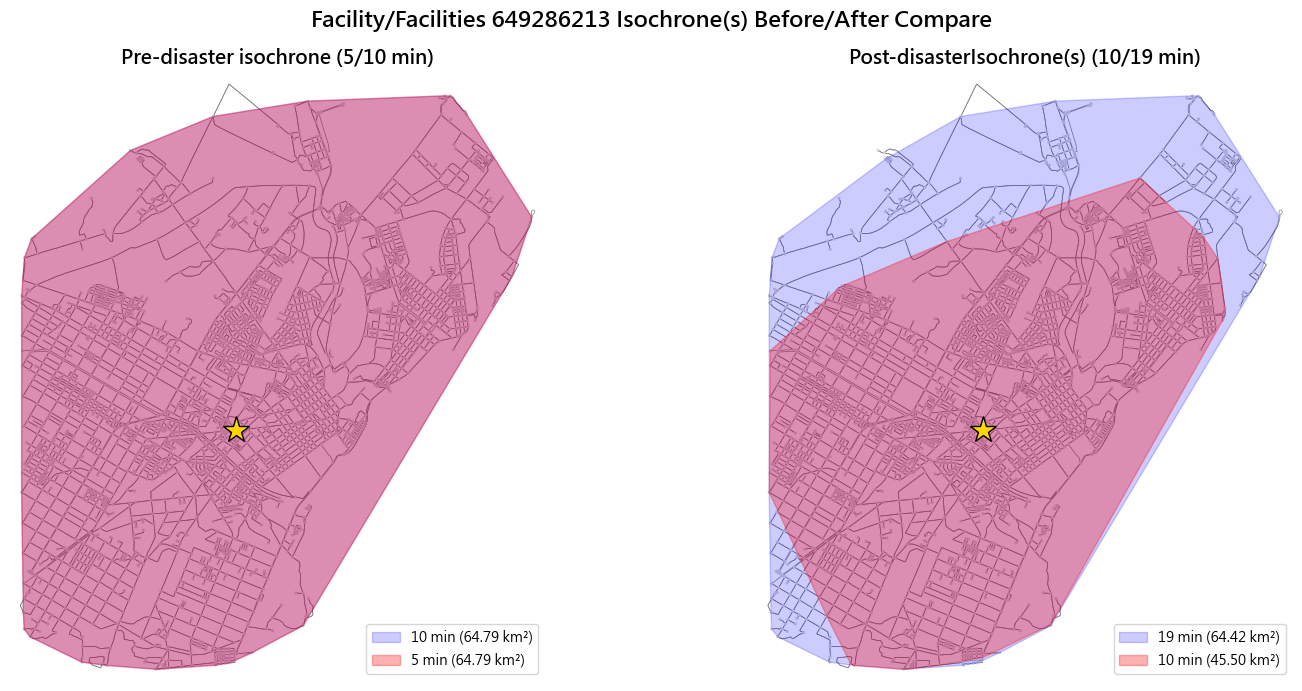

✅ Isochrone(s)Visualization complete


In [13]:
# [S13] Visualize Isochrone Comparison (Adaptive Threshold)

# Draw isochrones for the first critical facility
facility_id = selected_facilities[0][0]

# CalculatePre-disaster/Post-disasterrespective adaptive thresholds
t_short_b, t_long_b = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time')
t_short_a, t_long_a = get_adaptive_thresholds(G_dyn, facility_id, 'travel_time_adj')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

configs = [
    (axes[0], 'travel_time',     f'Pre-disaster isochrone ({t_short_b/60:.0f}/{t_long_b/60:.0f} min)', t_short_b, t_long_b),
    (axes[1], 'travel_time_adj', f'Post-disasterIsochrone(s) ({t_short_a/60:.0f}/{t_long_a/60:.0f} min)', t_short_a, t_long_a),
]

for ax, weight_attr, title, t_short, t_long in configs:
    # Draw background road network
    ox.plot_graph(G_proj, ax=ax, node_size=5, node_color='lightgray',
                 edge_color='gray', edge_linewidth=0.5, show=False)
    
    # CalculateIsochrone(s) (UseAdaptive threshold)
    reachable_short, _ = compute_isochrone(G_dyn, facility_id, weight_attr, t_short)
    reachable_long,  _ = compute_isochrone(G_dyn, facility_id, weight_attr, t_long)
    
    # to polygon and visualize
    poly_long,  area_long  = nodes_to_polygon(G_dyn, reachable_long)
    poly_short, area_short = nodes_to_polygon(G_dyn, reachable_short)
    
    if poly_long:
        x, y = poly_long.exterior.xy
        ax.fill(x, y, alpha=0.2, color='blue', label=f'{t_long/60:.0f} min ({area_long/1e6:.2f} km²)')
    if poly_short:
        x, y = poly_short.exterior.xy
        ax.fill(x, y, alpha=0.3, color='red', label=f'{t_short/60:.0f} min ({area_short/1e6:.2f} km²)')
    
    # Mark starting point
    fx = G_dyn.nodes[facility_id]['x']
    fy = G_dyn.nodes[facility_id]['y']
    ax.plot(fx, fy, marker='*', markersize=20, color='gold',
           markeredgecolor='black', zorder=10)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')

plt.suptitle(f'Facility/Facilities {facility_id} Isochrone(s) Before/After Compare', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Isochrone(s)Visualization complete")

## Part E: Professional Standards (Infrastructure First)

### Task E.1: Environment Variable Management


In [14]:
# [S14] .env Configuration Example

env_example = """
# Week 7 Network Analysis
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

# Threshold level classification (and Slide 12 Consistent)
# <10mm→cf=0, 10-40mm→cf=0.3, 40-80mm→cf=0.6, >80mm→cf=0.9
CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

# Isochrone Analysis
ISOCHRONE_MINUTES=5,10,15
ALPHA_SHAPE_ALPHA=0.001

# Data Paths
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
SHELTER_GEODATAFRAME_PATH=data/shelter_geodataframe.geojson
TERRAIN_RISK_PATH=data/terrain_risk.tif
"""

print("Recommended .env Configuration:")
print(env_example)

# TODO: Create in your project root directory .env file and fill in the above content

Recommended .env Configuration:

# Week 7 Network Analysis
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

# Threshold level classification (and Slide 12 Consistent)
# <10mm→cf=0, 10-40mm→cf=0.3, 40-80mm→cf=0.6, >80mm→cf=0.9
CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

# Isochrone Analysis
ISOCHRONE_MINUTES=5,10,15
ALPHA_SHAPE_ALPHA=0.001

# Data Paths
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
SHELTER_GEODATAFRAME_PATH=data/shelter_geodataframe.geojson
TERRAIN_RISK_PATH=data/terrain_risk.tif



### Task E.2: Save Graph as GraphML File


In [15]:
# [S15] Save Road Network as GraphML

import os
import osmnx as ox
os.makedirs("data", exist_ok=True)
graphml_path = "data/hualien_network.graphml"
ox.save_graphml(G_proj, graphml_path)
print("✅ Road network saved as GraphML")


✅ Road network saved as GraphML


## Part F: AI Strategic Report (Optional, Bonus)

### Task F.1: Use AI Tools to Generate Disaster Prevention Recommendations


In [16]:
# [S16] Prepare AI Tool Invocation

import os
from dotenv import load_dotenv
import google.generativeai as genai

# Load specific .env
load_dotenv("D:/YongZhi/2026_RS/.env")
api_key = os.getenv("GEMINI_API_KEY")
if api_key:
    genai.configure(api_key=api_key)
    print("✅ AI API Key Configured")
else:
    print("❌ API Key not found!")


✅ AI API Key Configured


In [17]:
# [S17] Generate AI Strategic Report

top_5_info = "\n".join([
    f"#{i}: Node(s) {node_id}, Centrality={cent:.4f}" 
    for i, (node_id, cent) in enumerate(top_5_nodes[:5], 1)
])

iso_table_str = accessibility_table.to_string()

prompt = f"""You are a traffic advisor for the Hualien County Disaster Prevention Command Center.

Below are the road network analysis results for Typhoon Fenghuang:

[Bottleneck intersection(s) Top 5]
{top_5_info}

[accessibilitybenefit-costtable]
{iso_table_str}

[AnalyzeTask(s)]
Please provide professional advice as a disaster prevention specialist,Provide the following recommendations:
1. most priority need rescue via road segment and/accessibility other reason
2. Alternative rescue methods for isolated areas (Helicopter, Rubber boats, etc.)
3. Resource allocation priority order
"""

try:
    model = genai.GenerativeModel('gemini-2.5-flash')
    response = model.generate_content(prompt)
    print("\n🤖 AI Strategy Report:")
    print(response.text)
except Exception as e:
    print("Could not generate report:", e)



🤖 AI Strategy Report:
To the Hualien County Disaster Prevention Command Center,

Based on the road network analysis results for Typhoon Fenghuang, here is a professional assessment and recommendations for immediate disaster response and resource allocation:

### 1. Most Priority Need for Rescue via Road Segment and/or Accessibility Other Reasons

The data clearly indicates severe impairment of road accessibility, particularly around the identified bottleneck nodes.

*   **Absolute Highest Priority Area:** The region impacted by **Node(s) 649286213** is the top priority.
    *   **Reasoning:** This node exhibits the highest centrality (0.1402), making it the single most critical point in the network whose failure has the widest impact. More critically, it shows an **80.6% contraction in accessible area within 5 minutes** post-disaster, reducing accessibility from 64.79 km² to a mere 12.59 km². This level of contraction strongly suggests severe road damage, complete washouts, large-scal

---

## Part G: AI Diagnostic Log (Required)

Record the problems you encountered and solutions in README.md::

### Common Issues Checklist

- [ ] 「OSMnx extractionTimeoutorIncomplete road network」
- [ ] 「Isochrone polygon shape anomaly (Has holes or too large)」  
- [ ] Kriging raster sampling returns nodata at road segment midpoints
- [ ] Road disconnectionAppeared later NetworkXNoPath — Island determination logic」
- [ ] 「road speed Default value strategy for missing attributes」


In [18]:
# [S18] Generate README.md Framework

readme_template = """# ARIA v4.0 - Hualien Disaster Accessibility Assessment

## Project Overview

This project builds an integrated automatic disaster accessibility assessment system combining road network, rainfall, and terrain data.

## datatosource

- **Road network**: OpenStreetMap (via OSMnx)
- **Rainfall**: Week 6 Kriging Interpolation result(s)
- **terrain**: Week 4 Terrain riskparttype
- **avoiddisasterall**: Week 3 avoiddisasterallpositionsettingandriverstreamdistancedistance

## AI diagnosticbreakdaylog

### 1. OSMnx extraction
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

### 2. Isochrone(s)multiplepolygon
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

### 3. Othercourseissue
**issueissue**: [describedescribeyouencounterto/reach issueissue]
**Solution(s)**: [you solutiondecisionmethod]

## corecenterissueappear

- Most fragile bottleneck: ???
- Maximum accessibility loss: ???
- Build rescue priority order: ???

## Submission Checklist

- [ ] ARIA_v4.ipynb (Complete integration and analysis)
- [ ] hualien_network.graphml (Road networkcountdata)
- [ ] README.md (This file + AI diagnosticbreakdaylog)
- [ ] accessibilitybenefit-costtable (DataFrame or CSV)
"""

with open('README_template.md', 'w', encoding='utf-8') as f:
    f.write(readme_template)

print("✅ README.md Framework generated,Please copy to your project")

✅ README.md Framework generated,Please copy to your project


---

## Submission Checklist

1. **GitHub Repo URL**
2. **ARIA_v4.ipynb** — Complete analysis notebook (including execution resultsresult)
3. **hualien_network.graphml** — Road networkcountdatafile
4. **README.md** — hullcontain AI diagnosticbreakdaylog
5. **accessibilitybenefit-costtable** — DataFrame or CSV Format

---

## EvaluationStandard

| itemobjective | compareweight |
|------|------|
| Road networkextractget + basethistravel time + GraphML Save/Archive | 15% |
| Betweenness Centrality + Top 5 Bottleneck + W4 Overlay | 20% |
| dynamicaccessibilityAnalyze (congestionvehicle + Isochrone(s) + contractioncompare) | 30% |
| professionalprojectstandard (.env + GraphML + README + AI daylog) | 15% |
| visualconvertitemquality (Road networklayer/map + Isochrone(s) before/after Compare) | 10% |
| **Bonus**: AI Strategy Report (Tools not limited) | 10% |

---

## Tips and Notes

1. **CRS Consistentproperty**: Road network、avoiddisasterall、Kriging raster All must be projected to EPSG:3826
2. **Speed defaultsetvalue**: OSM `maxspeed` normalnormalmissingloss,use highway typetyperecommendassess (see Demo Cell [3])
3. **Isochrone(s)multiplepolygon**: use `shapely`   `convex_hull` or `concave_hull`
4. **大typeRoad networkeffectcapability**: 花蓮 ~3000 nodes veryfast;allcountycancapabilityneedneed 1-2 partminute
5. **Kriging raster sampling**: Use `rasterio.sample()`, notecoordinatesystem
6. **road disconnectiondetermine**: cf = 0.9: speed reduced to 10%, nearly impassable;If you need to completely remove edges, use `G.remove_edge()`
7. **Threshold level classification**: `<10mm→0, 10-40mm→0.3, 40-80mm→0.6, >80mm→0.9` (and Slide 12 Consistent)